In [3]:
import os
import random
import numpy as np
import scipy.ndimage
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [5]:
def cbam_block(feature_map, ratio=8):
    channel = feature_map.shape[-1]

    # Channel Attention
    avg_pool = layers.GlobalAveragePooling2D()(feature_map)
    max_pool = layers.GlobalMaxPooling2D()(feature_map)

    shared_dense_one = layers.Dense(channel // ratio, activation='relu', kernel_initializer='he_normal')
    shared_dense_two = layers.Dense(channel, kernel_initializer='he_normal')

    avg_out = shared_dense_two(shared_dense_one(avg_pool))
    max_out = shared_dense_two(shared_dense_one(max_pool))

    channel_attention = layers.Add()([avg_out, max_out])
    channel_attention = layers.Activation('sigmoid')(channel_attention)
    channel_attention = layers.Reshape((1, 1, channel))(channel_attention)
    feature_map = layers.Multiply()([feature_map, channel_attention])

    # Spatial Attention
    avg_pool_spatial = tf.reduce_mean(feature_map, axis=3, keepdims=True)
    max_pool_spatial = tf.reduce_max(feature_map, axis=3, keepdims=True)
    concat = layers.Concatenate(axis=3)([avg_pool_spatial, max_pool_spatial])
    spatial_attention = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid', kernel_initializer='he_normal')(concat)
    feature_map = layers.Multiply()([feature_map, spatial_attention])

    return feature_map

In [6]:
def dense_block(x, num_layers, growth_rate):
    for _ in range(num_layers):
        y = layers.BatchNormalization()(x)
        y = layers.Activation('relu')(y)
        y = layers.Conv2D(4 * growth_rate, kernel_size=1, padding='same', use_bias=False)(y)
        y = layers.BatchNormalization()(y)
        y = layers.Activation('relu')(y)
        y = layers.Conv2D(growth_rate, kernel_size=3, padding='same', use_bias=False)(y)
        y = cbam_block(y)
        x = layers.Concatenate()([x, y])
    return x

In [7]:
def transition_block(x, reduction):
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(int(x.shape[-1] * reduction), kernel_size=1, use_bias=False)(x)
    x = layers.AveragePooling2D(pool_size=2, strides=2, padding='same')(x)
    return x

In [8]:
def build_densenet_cbam(input_shape=(224, 224, 3), num_classes=4, growth_rate=32):
    inputs = Input(shape=input_shape)
    x = layers.Conv2D(64, kernel_size=7, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    x = dense_block(x, 6, growth_rate)
    x = transition_block(x, 0.5)

    x = dense_block(x, 12, growth_rate)
    x = transition_block(x, 0.5)

    x = dense_block(x, 24, growth_rate)
    x = transition_block(x, 0.5)

    x = dense_block(x, 16, growth_rate)

    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

In [9]:
def create_generators(train_dir, val_dir, test_dir, target_size=(224, 224), batch_size=32):
    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2]
    )
    val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

    train_generator = train_datagen.flow_from_directory(train_dir, target_size=target_size, batch_size=batch_size, class_mode="categorical")
    val_generator = val_test_datagen.flow_from_directory(val_dir, target_size=target_size, batch_size=batch_size, class_mode="categorical")
    test_generator = val_test_datagen.flow_from_directory(test_dir, target_size=target_size, batch_size=batch_size, class_mode="categorical", shuffle=False)

    return train_generator, val_generator, test_generator

In [10]:
def train_model(model, train_generator, val_generator, epochs=20, learning_rate=1e-4):
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="categorical_crossentropy", metrics=["categorical_accuracy"])
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(train_generator, epochs=epochs, validation_data=val_generator, callbacks=[early_stop])
    return history

In [11]:
def fine_tune_model(model, train_generator, val_generator, fine_tune_epochs=10, fine_tune_lr=1e-5):
    model.trainable = True
    model.compile(optimizer=Adam(learning_rate=fine_tune_lr), loss="categorical_crossentropy", metrics=["categorical_accuracy"])
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history_fine = model.fit(train_generator, epochs=fine_tune_epochs, validation_data=val_generator, callbacks=[early_stop])
    return history_fine

In [12]:
def evaluate_model(model, test_generator):
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"Test Accuracy: {test_acc * 100:.2f}%")

    y_true = test_generator.classes
    y_pred = np.argmax(model.predict(test_generator), axis=1)
    print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [13]:
def plot_history(history, title='Model'):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["categorical_accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_categorical_accuracy"], label="Validation Accuracy")
    plt.legend()
    plt.title(f"{title} Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.legend()
    plt.title(f"{title} Loss")
    plt.show()

In [14]:
def main():
    set_seed()
    dataset_path = r"C:\Users\User\Desktop\Diseases\Dataset"
    train_dir = os.path.join(dataset_path, "train")
    val_dir = os.path.join(dataset_path, "val")
    test_dir = os.path.join(dataset_path, "test")

    train_generator, val_generator, test_generator = create_generators(train_dir, val_dir, test_dir)

    model = build_densenet_cbam()
    history = train_model(model, train_generator, val_generator)
    plot_history(history, title="CBAM DenseNet")

    history_fine = fine_tune_model(model, train_generator, val_generator)
    plot_history(history_fine, title="CBAM DenseNet Fine Tune")

    evaluate_model(model, test_generator)
    model.save("EyeNet_Final_Model.h5")
    print("Model saved as EyeNet_Final_Model.h5")

Found 36462 images belonging to 4 classes.
Found 7812 images belonging to 4 classes.
Found 7820 images belonging to 4 classes.
Epoch 1/20
1140/1140 [==============================] - 268s 211ms/step - loss: 3.1036 - categorical_accuracy: 0.5646 - val_loss: 1.9040 - val_categorical_accuracy: 0.6105
Epoch 2/20
1140/1140 [==============================] - 227s 199ms/step - loss: 1.3137 - categorical_accuracy: 0.7058 - val_loss: 1.3702 - val_categorical_accuracy: 0.5892
Epoch 3/20
1140/1140 [==============================] - 238s 208ms/step - loss: 0.7814 - categorical_accuracy: 0.7689 - val_loss: 0.8558 - val_categorical_accuracy: 0.7037
Epoch 4/20
1140/1140 [==============================] - 230s 202ms/step - loss: 0.5528 - categorical_accuracy: 0.8181 - val_loss: 0.5545 - val_categorical_accuracy: 0.7960
Epoch 5/20
1140/1140 [==============================] - 217s 190ms/step - loss: 0.4458 - categorical_accuracy: 0.8451 - val_loss: 0.4485 - val_categorical_accuracy: 0.8391
Epoch 6/20
11

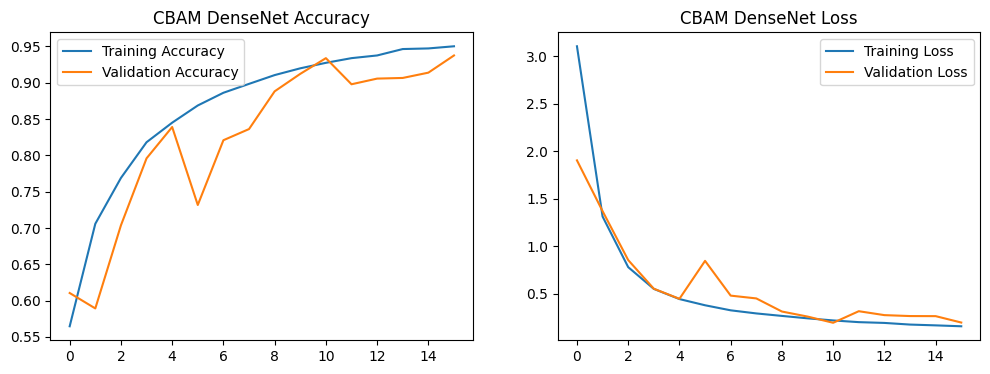

Epoch 1/10
1140/1140 [==============================] - 243s 201ms/step - loss: 0.1511 - categorical_accuracy: 0.9541 - val_loss: 0.1425 - val_categorical_accuracy: 0.9569
Epoch 2/10
1140/1140 [==============================] - 225s 197ms/step - loss: 0.1319 - categorical_accuracy: 0.9615 - val_loss: 0.1423 - val_categorical_accuracy: 0.9571
Epoch 3/10
1140/1140 [==============================] - 224s 197ms/step - loss: 0.1184 - categorical_accuracy: 0.9646 - val_loss: 0.1337 - val_categorical_accuracy: 0.9611
Epoch 4/10
1140/1140 [==============================] - 226s 198ms/step - loss: 0.1134 - categorical_accuracy: 0.9678 - val_loss: 0.1239 - val_categorical_accuracy: 0.9616
Epoch 5/10
1140/1140 [==============================] - 225s 197ms/step - loss: 0.1087 - categorical_accuracy: 0.9696 - val_loss: 0.1249 - val_categorical_accuracy: 0.9619
Epoch 6/10
1140/1140 [==============================] - 226s 198ms/step - loss: 0.1029 - categorical_accuracy: 0.9699 - val_loss: 0.1140 - v

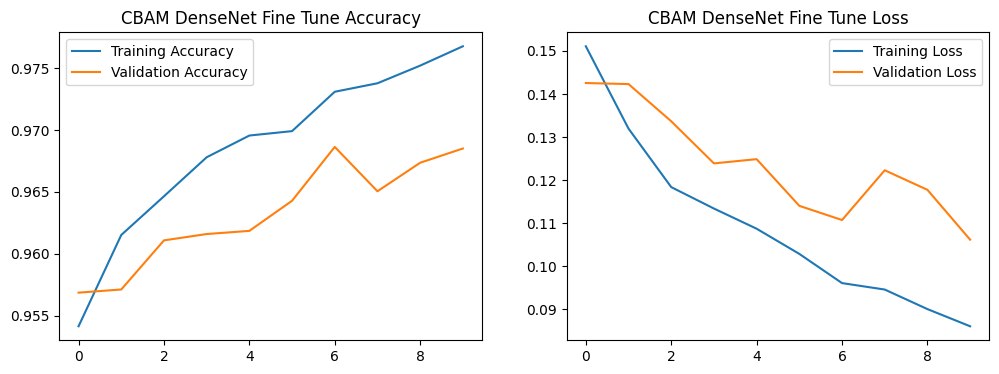

245/245 [==============================] - 15s 60ms/step - loss: 0.0915 - categorical_accuracy: 0.9746
Test Accuracy: 97.46%
245/245 [==============================] - 15s 52ms/step
                precision    recall  f1-score   support

      Cataract       0.98      0.97      0.97      1955
Conjunctivitis       0.98      0.97      0.98      1955
       Healthy       0.97      0.97      0.97      1955
          Stye       0.97      0.99      0.98      1955

      accuracy                           0.97      7820
     macro avg       0.97      0.97      0.97      7820
  weighted avg       0.97      0.97      0.97      7820



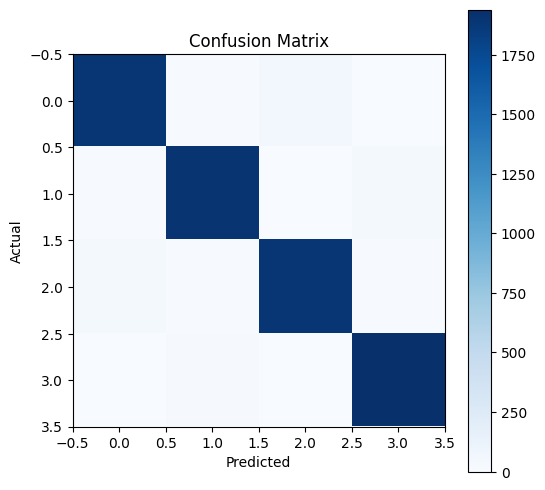

Model saved as EyeNet_Final_Model.h5


In [15]:
main()